In [1]:
#Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.ensemble import VotingClassifier

#define a function that will be used later for cunfusion matrix
def display_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm).plot()
    





(70000, 784)
(70000,)
True label for the plotted image is 5


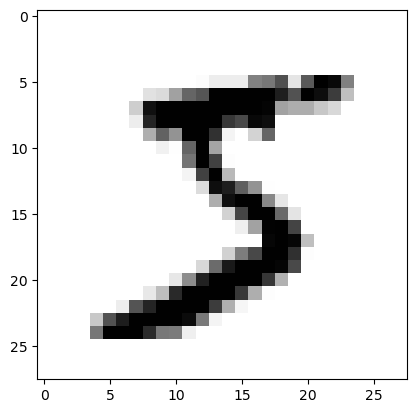

In [2]:
#load data
mnist = fetch_openml('mnist_784', version=1, cache=True, as_frame=False)
X = mnist["data"]
y = mnist["target"].astype(np.uint8)
print(X.shape)
print(y.shape)

some_digit = X[0]
some_digit_image = some_digit.reshape(28, 28)
plt.imshow(some_digit_image, cmap=mpl.cm.binary)
print("True label for the plotted image is", y[0])


In [ ]:
#Splitting data
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=20000, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=20000, random_state=42)

#Scaling data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

#train 3 models and then combine them in a voiting classifier
logreg_clf = LogisticRegression(max_iter=1000)
random_forest_clf = RandomForestClassifier(n_estimators=100, random_state=42)
extra_trees_clf = ExtraTreesClassifier(n_estimators=100, random_state=42)

named_estimators = [
    ("logreg_clf", logreg_clf),
    ("random_forest_clf", random_forest_clf),
    ("extra_tree_clf", extra_trees_clf)
]
voting_clf = VotingClassifier(named_estimators, voting='hard')

models = [logreg_clf, random_forest_clf, extra_trees_clf, voting_clf]
for model in models:
    model.fit(X_train, y_train)
    
print("Accuracy for each model")
model_names = ["Logistic Regression", "Random Forest", "Extra trees", "Voting Classifier"]
for name, model in zip(model_names, models):
    score = model.score(X_val, y_val)
    print(f"{name:20s}: {score:.4f}")


Accuracy for each model
Logistic Regression : 0.9039
Random Forest       : 0.9617
Extra trees         : 0.9656
Voting Classifier   : 0.9646


              precision    recall  f1-score   support

           0       0.97      0.98      0.98      1944
           1       0.99      0.98      0.98      2250
           2       0.96      0.96      0.96      1940
           3       0.96      0.95      0.96      2116
           4       0.97      0.97      0.97      2017
           5       0.97      0.96      0.96      1836
           6       0.97      0.98      0.98      1991
           7       0.97      0.96      0.97      2005
           8       0.95      0.95      0.95      1896
           9       0.95      0.95      0.95      2005

    accuracy                           0.97     20000
   macro avg       0.97      0.97      0.97     20000
weighted avg       0.97      0.97      0.97     20000



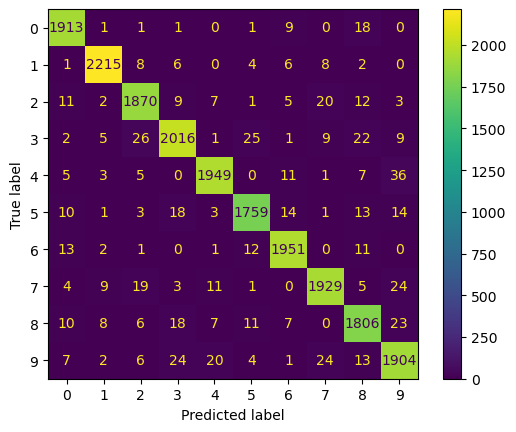

In [4]:
#create confusion matrix and classification report for the best model. Best model extra_trees
et_pred_val = extra_trees_clf.predict(X_val)
display_confusion_matrix(y_val, et_pred_val)
print(classification_report(y_val, et_pred_val))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1966
           1       0.98      0.99      0.98      2240
           2       0.96      0.97      0.96      2039
           3       0.96      0.96      0.96      2061
           4       0.97      0.97      0.97      1831
           5       0.98      0.96      0.97      1822
           6       0.98      0.99      0.98      1995
           7       0.97      0.97      0.97      2156
           8       0.97      0.95      0.96      1912
           9       0.95      0.95      0.95      1978

    accuracy                           0.97     20000
   macro avg       0.97      0.97      0.97     20000
weighted avg       0.97      0.97      0.97     20000



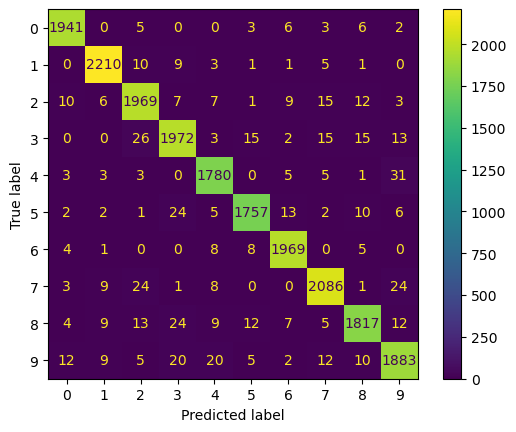

In [5]:
#Refit model on train + validation data
X_train_val = scaler.fit_transform(X_train_val)
extra_trees_clf.fit(X_train_val, y_train_val)

#Evaluate it on test data
et_pred_test = extra_trees_clf.predict(X_test)
display_confusion_matrix(y_test, et_pred_test)
print(classification_report(y_test, et_pred_test))


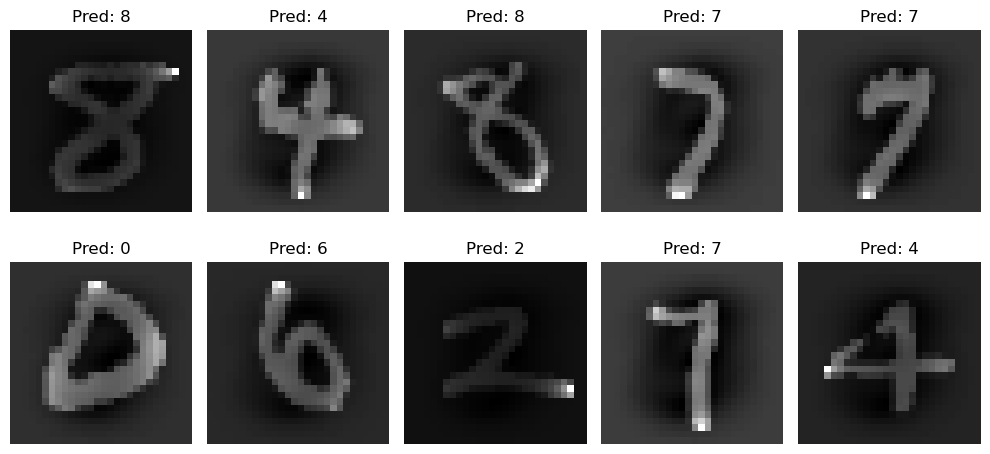

In [6]:
# Visualize some predictions
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
axes = axes.ravel()

for i in range(10):
    axes[i].imshow(X_test[i].reshape(28, 28), cmap='gray')
    axes[i].set_title(f"Pred: {y_test[i]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()
